In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import median_abs_deviation

In [2]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.titlesize': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 12,

    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',

    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True
})

In [3]:
def format_plot(ax, title, xlabel, ylabel, horizontal=False):

    ax.set_title(title, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if horizontal:
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.grid(axis='y', visible=False)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', visible=False)

In [4]:
filePath = '../../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)

In [5]:
def get_clean_mask(data, threshold=3.5):
    """
    Apply Iglewicz and Hoaglin's robust outlier detection.
    Returns: Boolean mask (True = Valid, False = Outlier)
    """
    median = np.median(data)
    mad = median_abs_deviation(data, scale='normal')
    modified_z_score = 0.6745 * (data - median) / mad
    return modified_z_score.abs() < threshold

In [6]:
df_bmi_profile = df[['Height','Weight','Body Mass Index (BMI)','Obesity (%)']].copy()

# 1. Calculate BMI
# Formula: Weight / (Height in m)^2
df_bmi_profile['Calculated BMI'] = df_bmi_profile['Weight'] / ((df_bmi_profile['Height'] / 100) ** 2)

# 2. Calculate BMI Residual
# Logic: | Reported - Calculated |
df_bmi_profile['BMI Analysis (Residual)'] = df_bmi_profile['Body Mass Index (BMI)'] - df_bmi_profile['Calculated BMI']

df_bmi_profile['BMI Analysis (Mean)'] = (df_bmi_profile['Body Mass Index (BMI)'] + df_bmi_profile['Calculated BMI'])/ 2

df_bmi_profile

,Height,Weight,Body Mass Index (BMI),Obesity (%),Calculated BMI,BMI Analysis (Residual),BMI Analysis (Mean)
0,185,92.8,27.1,23.40,27.114682,-0.014682,27.107341
1,176,94.5,30.5,38.80,30.507490,-0.007490,30.503745
2,171,91.1,31.2,41.70,31.154885,0.045115,31.177443
3,168,67.7,24.0,9.00,23.986678,0.013322,23.993339
4,178,89.6,28.3,28.60,28.279258,0.020742,28.289629
...,...,...,...,...,...,...,...
314,178,88.8,28.0,14.39,28.026764,-0.026764,28.013382
315,157,53.4,21.7,1.50,21.664165,0.035835,21.682082
316,172,96.6,32.7,48.40,32.652785,0.047215,32.676393
317,177,88.4,28.2,28.30,28.216668,-0.016668,28.208334


In [7]:
# === Cell 6: Data Repair Logic (Imputation Strategy) ===
# Logic: Identify outliers via Modified Z-Score > 3.5
# Action: Repair outliers by replacing 'Reported BMI' with 'Calculated BMI'

target_col = 'BMI Analysis (Residual)'

# 1. 识别异常 (Identify)
# 这一步使用 Modified Z-Score 找出物理上不合理的点
is_valid_mask = get_clean_mask(df_bmi_profile[target_col], threshold=3.5)

# 2. 执行修复 (Repair)
# 创建新列 'BMI_Final'
# 如果是正常点 -> 保持原值
# 如果是异常点 -> 用物理计算值 (Calculated BMI) 覆盖
df_bmi_profile['BMI_Final'] = np.where(
    is_valid_mask,
    df_bmi_profile['Body Mass Index (BMI)'],  # Keep Original
    df_bmi_profile['Calculated BMI']          # Fix with Ground Truth
)

# 3. 创建状态标签 (用于绘图区分颜色)
df_bmi_profile['Data Status'] = np.where(
    is_valid_mask,
    'Original (Verified)',
    'Repaired (Was Outlier)'
)

# 4. 重新计算修复后的残差 (用于 Bland-Altman)
df_bmi_profile['Residual_Final'] = df_bmi_profile['BMI_Final'] - df_bmi_profile['Calculated BMI']
df_bmi_profile['Mean_Final'] = (df_bmi_profile['BMI_Final'] + df_bmi_profile['Calculated BMI']) / 2

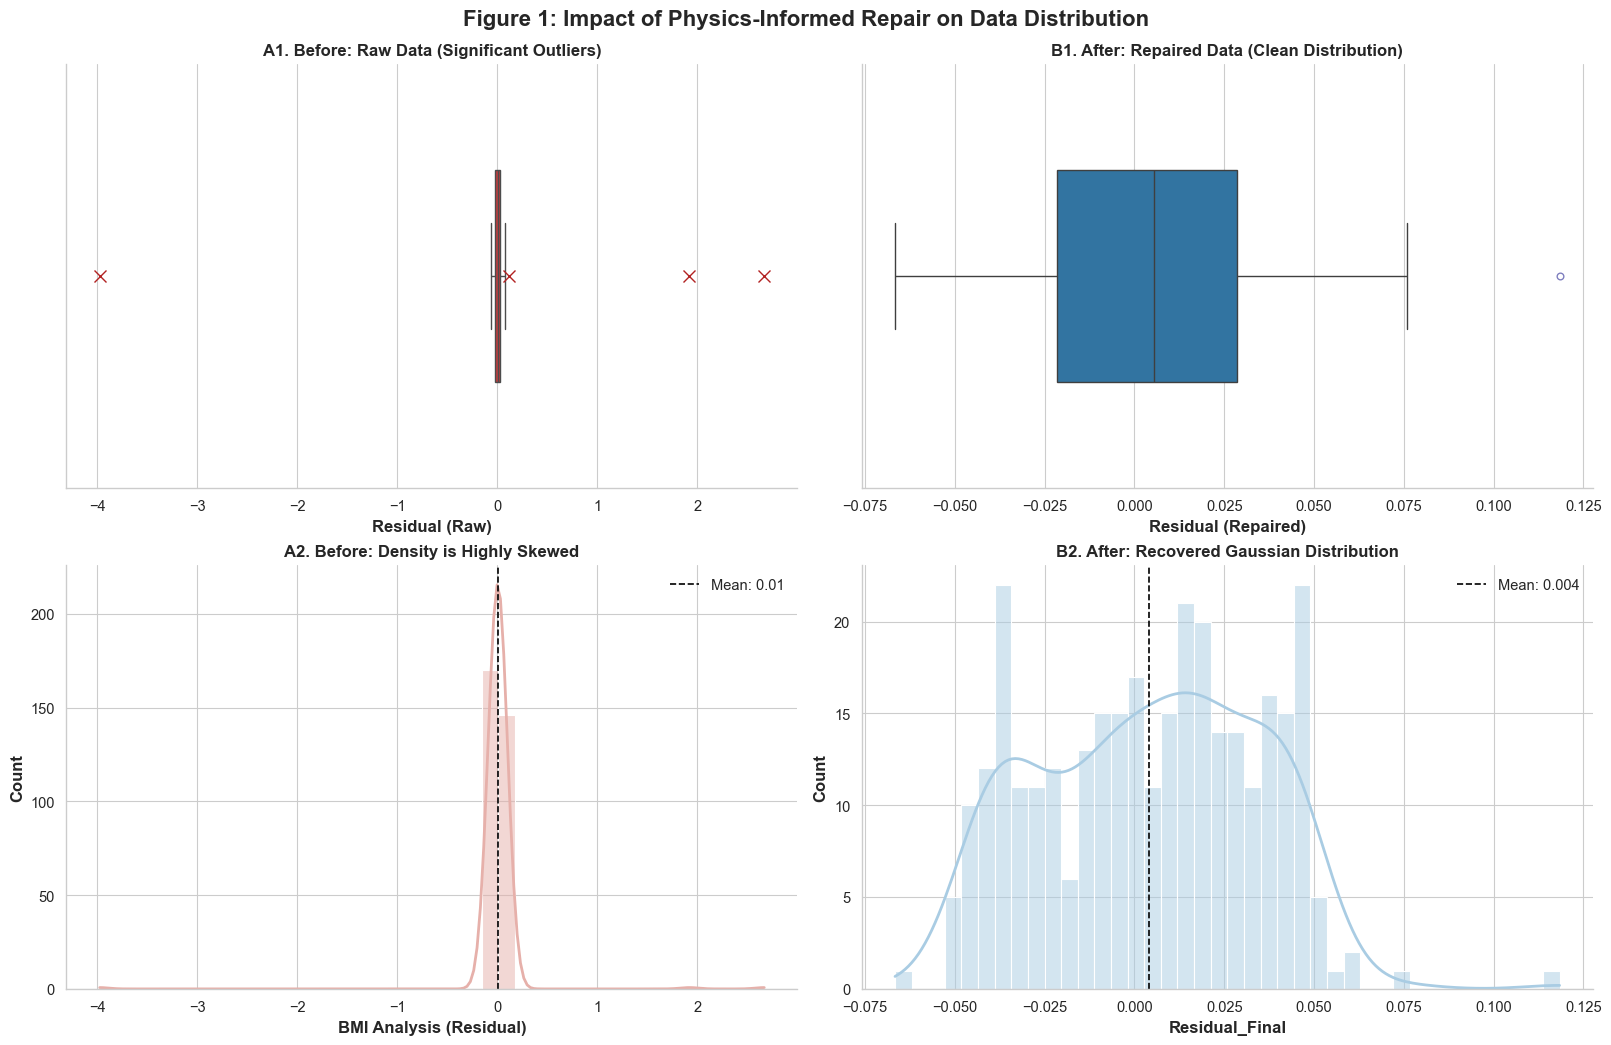

In [8]:
# === Cell 7: Figure 1 - Distribution Contrast (Before vs. After) ===
# Purpose: Prove that skewness is eliminated and distribution is restored.

# 准备数据视图
raw_residuals = df_bmi_profile['BMI Analysis (Residual)']
repaired_residuals = df_bmi_profile['Residual_Final']

# 设置画布
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

# -----------------------------
# Column 1: Before Repair (Raw)
# -----------------------------
# A1. Boxplot
sns.boxplot(x=raw_residuals, ax=axes[0,0], color='tab:red', width=0.5,
            flierprops={"marker": "x", "markeredgecolor": "firebrick", "markersize": 8})
axes[0,0].set_title("A1. Before: Raw Data (Significant Outliers)", fontweight='bold', fontsize=12)
axes[0,0].set_xlabel("Residual (Raw)")

# A2. Histogram (Skewed)
sns.histplot(x=raw_residuals, ax=axes[1,0], color='#E6B0AA', bins=40, kde=True, line_kws={'linewidth': 2})
axes[1,0].axvline(raw_residuals.mean(), color='black', linestyle='--', label=f'Mean: {raw_residuals.mean():.2f}')
axes[1,0].set_title("A2. Before: Density is Highly Skewed", fontweight='bold', fontsize=12)
axes[1,0].legend()

# -----------------------------
# Column 2: After Repair (Fixed)
# -----------------------------
# B1. Boxplot
sns.boxplot(x=repaired_residuals, ax=axes[0,1], color='tab:blue', width=0.5,
            flierprops={"marker": "o", "markeredgecolor": "navy", "alpha": 0.5})
axes[0,1].set_title("B1. After: Repaired Data (Clean Distribution)", fontweight='bold', fontsize=12)
axes[0,1].set_xlabel("Residual (Repaired)")

# B2. Histogram (Gaussian)
sns.histplot(x=repaired_residuals, ax=axes[1,1], color='#A9CCE3', bins=40, kde=True, line_kws={'linewidth': 2})
axes[1,1].axvline(repaired_residuals.mean(), color='black', linestyle='--', label=f'Mean: {repaired_residuals.mean():.3f}')
axes[1,1].set_title(f"B2. After: Recovered Gaussian Distribution", fontweight='bold', fontsize=12)
axes[1,1].legend()

plt.suptitle("Figure 1: Impact of Physics-Informed Repair on Data Distribution", y=1.03, fontsize=16, fontweight='bold')
plt.show()

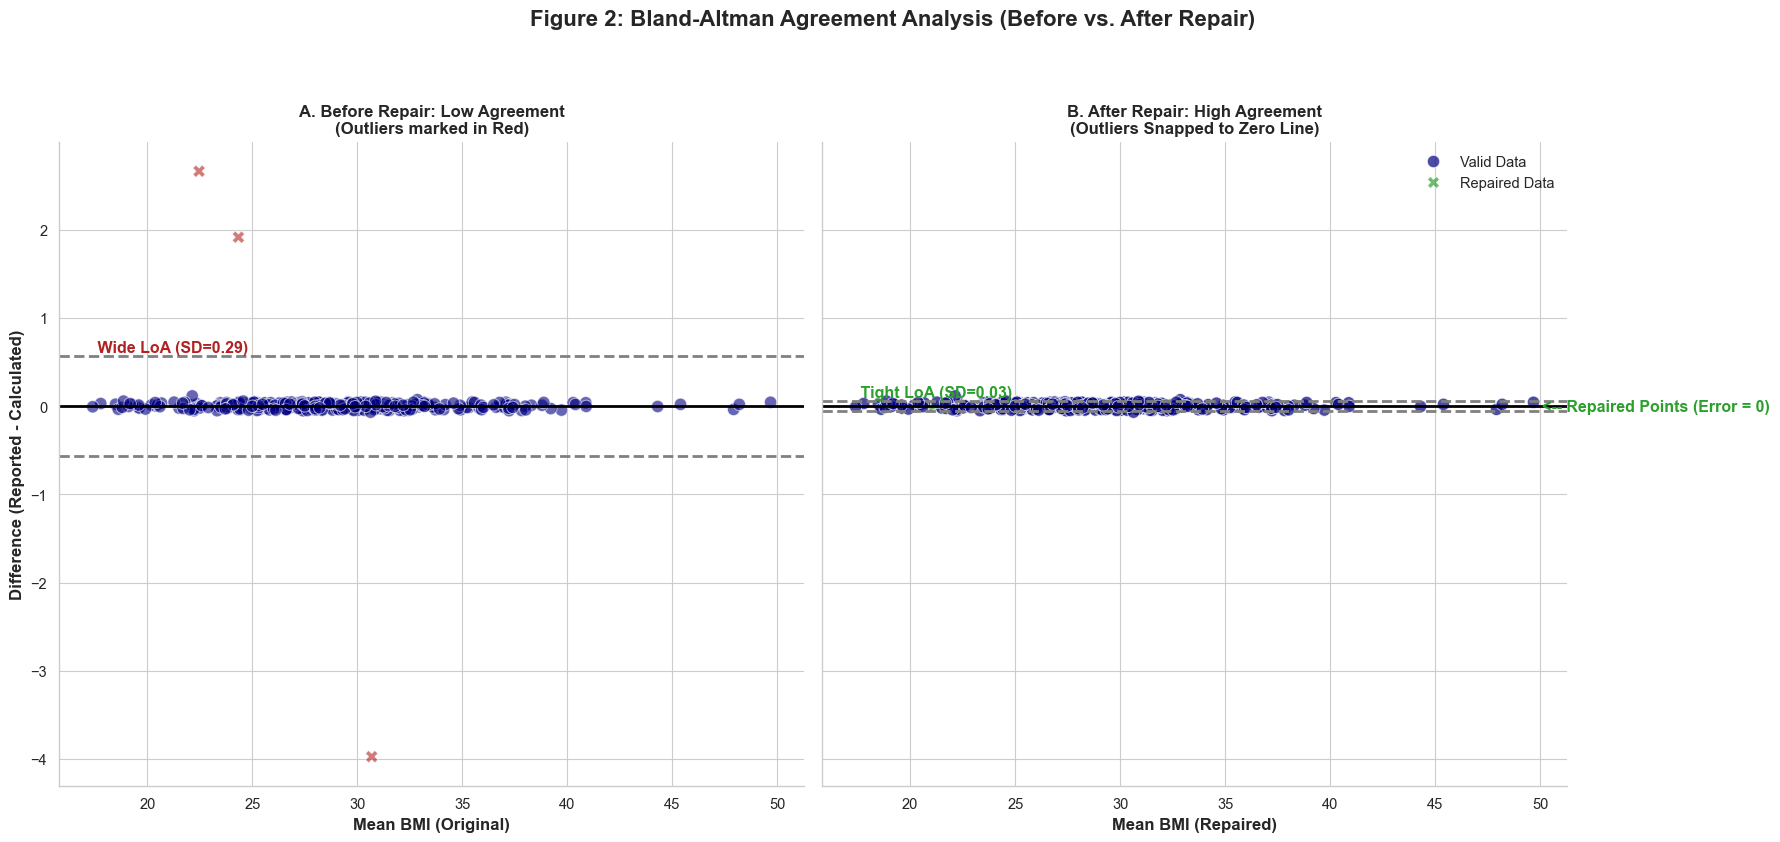

In [9]:
# === Cell 8: Figure 2 - Bland-Altman Comparison (Side-by-Side) ===
# Purpose: Visual proof that the 'Repair Method' creates statistical agreement.

# 设置画布：1行2列
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# 颜色映射
palette_raw = {'Original (Verified)': 'navy', 'Repaired (Was Outlier)': 'firebrick'}
palette_fix = {'Original (Verified)': 'navy', 'Repaired (Was Outlier)': 'tab:green'}
markers = {'Original (Verified)': 'o', 'Repaired (Was Outlier)': 'X'}

# ==========================================
# 左图：修复前 (Before Repair) - 暴露问题
# ==========================================
ax1 = axes[0]
sns.scatterplot(data=df_bmi_profile, x='BMI Analysis (Mean)', y='BMI Analysis (Residual)',
                hue='Data Status', palette=palette_raw, style='Data Status', markers=markers,
                s=80, alpha=0.6, ax=ax1, legend=False)

# 统计线 (基于原始数据)
mean_raw = df_bmi_profile['BMI Analysis (Residual)'].mean()
sd_raw = df_bmi_profile['BMI Analysis (Residual)'].std()
ax1.axhline(mean_raw, color='black', ls='-', lw=2)
ax1.axhline(mean_raw + 1.96*sd_raw, color='gray', ls='--', lw=2)
ax1.axhline(mean_raw - 1.96*sd_raw, color='gray', ls='--', lw=2)

# 标注
ax1.set_title("A. Before Repair: Low Agreement\n(Outliers marked in Red)", fontweight='bold', fontsize=12)
ax1.set_xlabel("Mean BMI (Original)")
ax1.set_ylabel("Difference (Reported - Calculated)")
ax1.text(df_bmi_profile['BMI Analysis (Mean)'].min(), mean_raw + 1.96*sd_raw,
         f' Wide LoA (SD={sd_raw:.2f})', color='firebrick', va='bottom', fontweight='bold')

# ==========================================
# 右图：修复后 (After Repair) - 验证方案
# ==========================================
ax2 = axes[1]
sns.scatterplot(data=df_bmi_profile, x='Mean_Final', y='Residual_Final',
                hue='Data Status', palette=palette_fix, style='Data Status', markers=markers,
                s=80, alpha=0.7, ax=ax2)

# 统计线 (基于修复后数据)
mean_fix = df_bmi_profile['Residual_Final'].mean()
sd_fix = df_bmi_profile['Residual_Final'].std() # 这里的 SD 应该极小
ax2.axhline(mean_fix, color='black', ls='-', lw=2)
ax2.axhline(mean_fix + 1.96*sd_fix, color='gray', ls='--', lw=2)
ax2.axhline(mean_fix - 1.96*sd_fix, color='gray', ls='--', lw=2)

# 标注
ax2.set_title("B. After Repair: High Agreement\n(Outliers Snapped to Zero Line)", fontweight='bold', fontsize=12)
ax2.set_xlabel("Mean BMI (Repaired)")
# 标注绿色修复点
ax2.text(df_bmi_profile['Mean_Final'].max(), 0, "  <-- Repaired Points (Error = 0)",
         color='tab:green', va='center', ha='left', fontweight='bold')
ax2.text(df_bmi_profile['Mean_Final'].min(), mean_fix + 1.96*sd_fix,
         f' Tight LoA (SD={sd_fix:.2f})', color='tab:green', va='bottom', fontweight='bold')

# 图例优化
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, ['Valid Data', 'Repaired Data'], loc='upper right')

plt.suptitle("Figure 2: Bland-Altman Agreement Analysis (Before vs. After Repair)", y=1.05, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ==============================================================================
# CELL 1: FORENSIC ALGORITHM & CLASSIFICATION
# ==============================================================================

# 1. 物理层验证：重算 BMI (作为 Ground Truth)
df_bmi_profile['BMI_Final'] = df_bmi_profile['Weight'] / ((df_bmi_profile['Height'] / 100) ** 2)

# 2. 准备数据：计算相对于 Standard 22 的残差
theoretical_obesity_22 = np.abs((df_bmi_profile['BMI_Final'] - 22) / 22) * 100
df_bmi_profile['Forensic_Residual_22'] = df_bmi_profile['Obesity (%)'] - theoretical_obesity_22

# 3. 逆向工程：计算每行数据对应的"隐含标准"
df_bmi_profile['Implied_Std_Heavy'] = df_bmi_profile['BMI_Final'] / (1 + df_bmi_profile['Obesity (%)'] / 100)
df_bmi_profile['Implied_Std_Light'] = df_bmi_profile['BMI_Final'] / (1 - df_bmi_profile['Obesity (%)'] / 100)

# 4. 匹配算法 (4 标准逻辑)
def match_std(target, tol=0.4):
    match_h = (df_bmi_profile['Implied_Std_Heavy'] >= target - tol) & (df_bmi_profile['Implied_Std_Heavy'] <= target + tol)
    match_l = (df_bmi_profile['Implied_Std_Light'] >= target - tol) & (df_bmi_profile['Implied_Std_Light'] <= target + tol) & (df_bmi_profile['Obesity (%)'] < 100)
    return match_h | match_l

# 定义四个已知的医学标准
conditions = [
    match_std(22.0),
    match_std(23.5),
    match_std(24.5),
    match_std(25.5)
]
choices = [
    'Standard 22 (Ideal)',
    'Standard 23.5 (Asian Cutoff)',
    'Standard 24.5 (Overweight)',
    'Standard 25.5 (Obese I)'
]

# 应用分类
df_bmi_profile['Forensic_Group'] = np.select(conditions, choices, default='Unclassified')

# 5. 标记 Scaling Error (1954%)
# 注意：这里只打标，不修改原始数据，修改在 Cell 4 展示
mask_scaling = df_bmi_profile['Obesity (%)'] > 1000
df_bmi_profile.loc[mask_scaling, 'Forensic_Group'] = 'Scaling Error (1954%)'

# 6. 计算模型残差 (用于验证分类准确性)
def get_theoretical_obesity(row):
    bmi = row['BMI_Final']
    if row['Forensic_Group'] == 'Standard 22 (Ideal)': std = 22.0
    elif row['Forensic_Group'] == 'Standard 23.5 (Asian Cutoff)': std = 23.5
    elif row['Forensic_Group'] == 'Standard 24.5 (Overweight)': std = 24.5
    elif row['Forensic_Group'] == 'Standard 25.5 (Obese I)': std = 25.5
    else: return row['Obesity (%)']
    return np.abs((bmi - std) / std) * 100

df_bmi_profile['Model_Residual'] = df_bmi_profile.apply(lambda row: row['Obesity (%)'] - get_theoretical_obesity(row), axis=1)

# 定义全局统一配色方案
FORENSIC_PALETTE = {
    'Standard 22 (Ideal)': 'navy',
    'Standard 23.5 (Asian Cutoff)': 'rebeccapurple',
    'Standard 24.5 (Overweight)': 'orange',
    'Standard 25.5 (Obese I)': 'forestgreen',
    'Unclassified': 'gray',
    'Scaling Error (1954%)': 'red'
}

C:\Users\yqn1e23\AppData\Local\Temp\ipykernel_19336\3869059491.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=plot_data.values, y=plot_data.index, palette=FORENSIC_PALETTE)


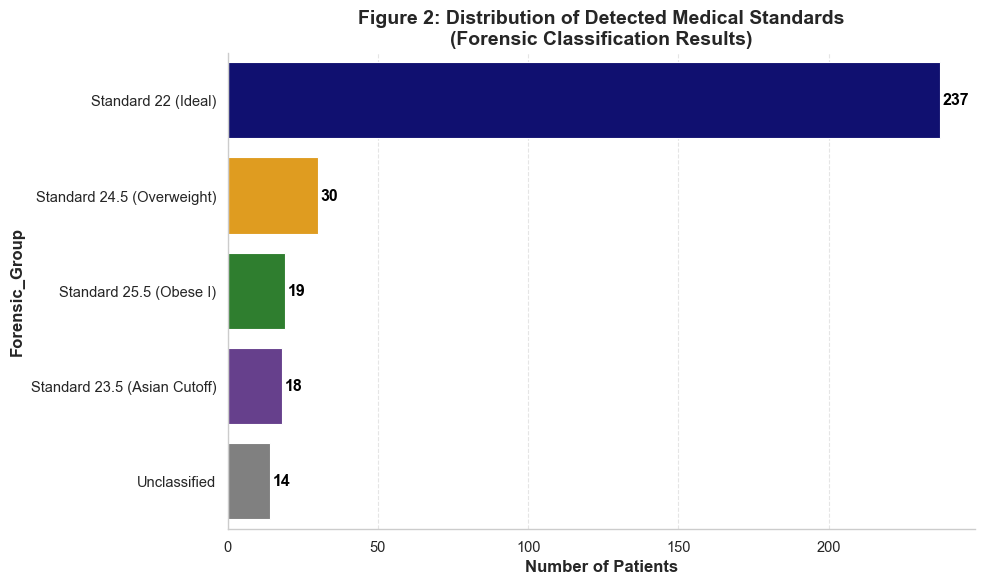

In [11]:
# ==============================================================================
# FIGURE 2: DISTRIBUTION OF DETECTED STANDARDS
# ==============================================================================

plt.figure(figsize=(10, 6))
# 排除 Scaling Error 以便展示主要分布
plot_data = df_bmi_profile[df_bmi_profile['Forensic_Group'] != 'Scaling Error (1954%)']['Forensic_Group'].value_counts()

ax = sns.barplot(x=plot_data.values, y=plot_data.index, palette=FORENSIC_PALETTE)

# 添加数值标签
for i, v in enumerate(plot_data.values):
    ax.text(v + 1, i, str(v), color='black', va='center', fontweight='bold')

plt.title('Figure 2: Distribution of Detected Medical Standards\n(Forensic Classification Results)', fontweight='bold', fontsize=14)
plt.xlabel('Number of Patients')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

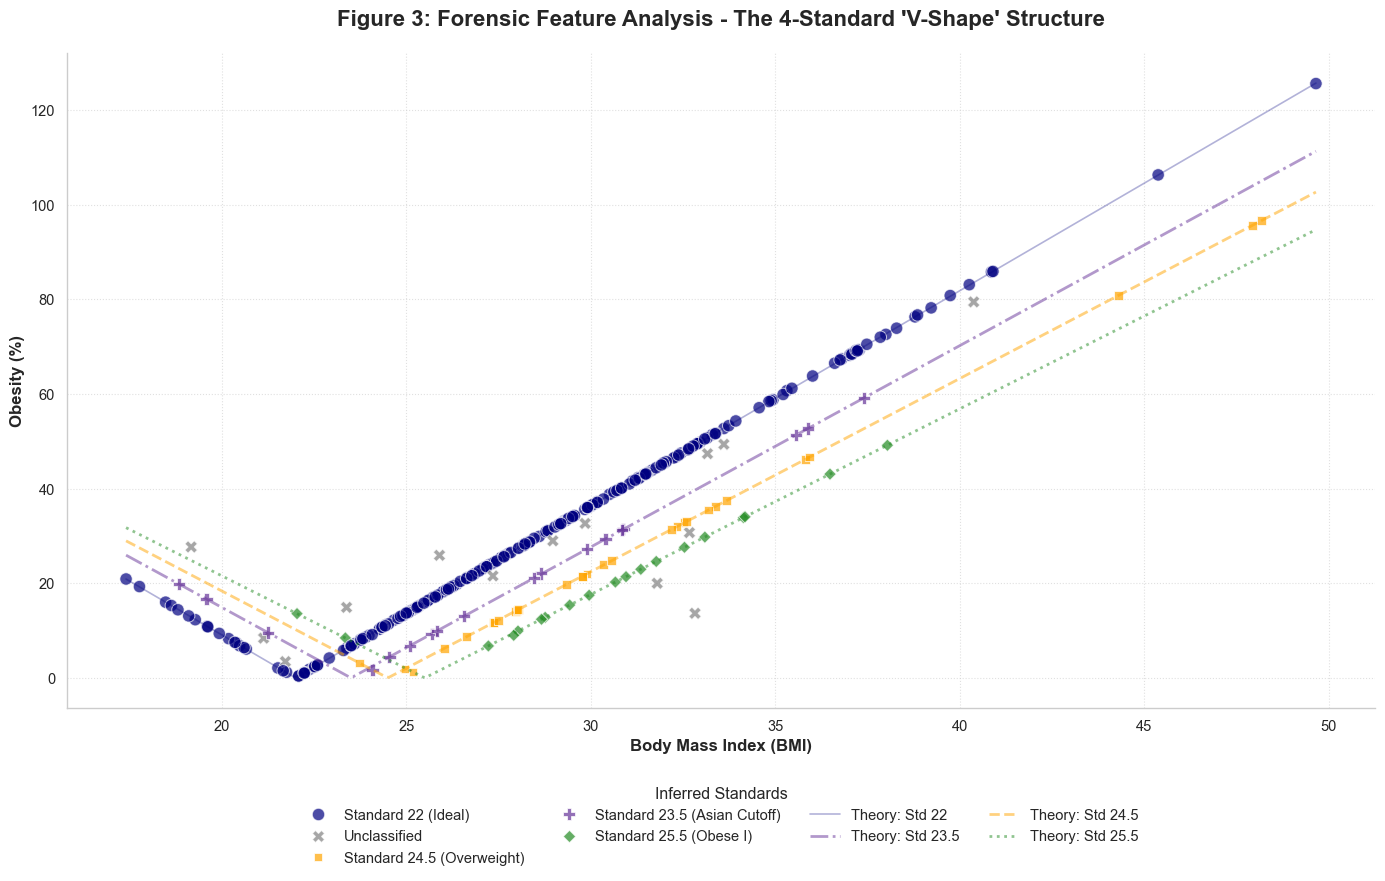

In [12]:
# ==============================================================================
# FIGURE 3: THE "V-SHAPE" PHENOMENON (Structural Evidence)
# ==============================================================================

plt.figure(figsize=(14, 9))

plot_df = df_bmi_profile[df_bmi_profile['Obesity (%)'] < 500]

# 1. 绘制散点
sns.scatterplot(data=plot_df, x='BMI_Final', y='Obesity (%)',
                hue='Forensic_Group', style='Forensic_Group',
                palette=FORENSIC_PALETTE,
                s=80, alpha=0.7)

# 2. 绘制四条理论线
x_range = np.linspace(plot_df['BMI_Final'].min(), plot_df['BMI_Final'].max(), 300)

plt.plot(x_range, np.abs((x_range-22)/22)*100, color='navy', alpha=0.3, label='Theory: Std 22')
plt.plot(x_range, np.abs((x_range-23.5)/23.5)*100, color='rebeccapurple', ls='-.', alpha=0.5, lw=2, label='Theory: Std 23.5')
plt.plot(x_range, np.abs((x_range-24.5)/24.5)*100, color='orange', ls='--', alpha=0.5, lw=2, label='Theory: Std 24.5')
plt.plot(x_range, np.abs((x_range-25.5)/25.5)*100, color='forestgreen', ls=':', alpha=0.5, lw=2, label='Theory: Std 25.5')

plt.title("Figure 3: Forensic Feature Analysis - The 4-Standard 'V-Shape' Structure", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Body Mass Index (BMI)", fontweight='bold')
plt.ylabel("Obesity (%)", fontweight='bold')
plt.legend(title='Inferred Standards', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

C:\Users\yqn1e23\AppData\Local\Temp\ipykernel_19336\2158091298.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=boxplot_df, x='Forensic_Group', y='Model_Residual',
C:\Users\yqn1e23\AppData\Local\Temp\ipykernel_19336\2158091298.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(new_labels, rotation=15, fontweight='bold')


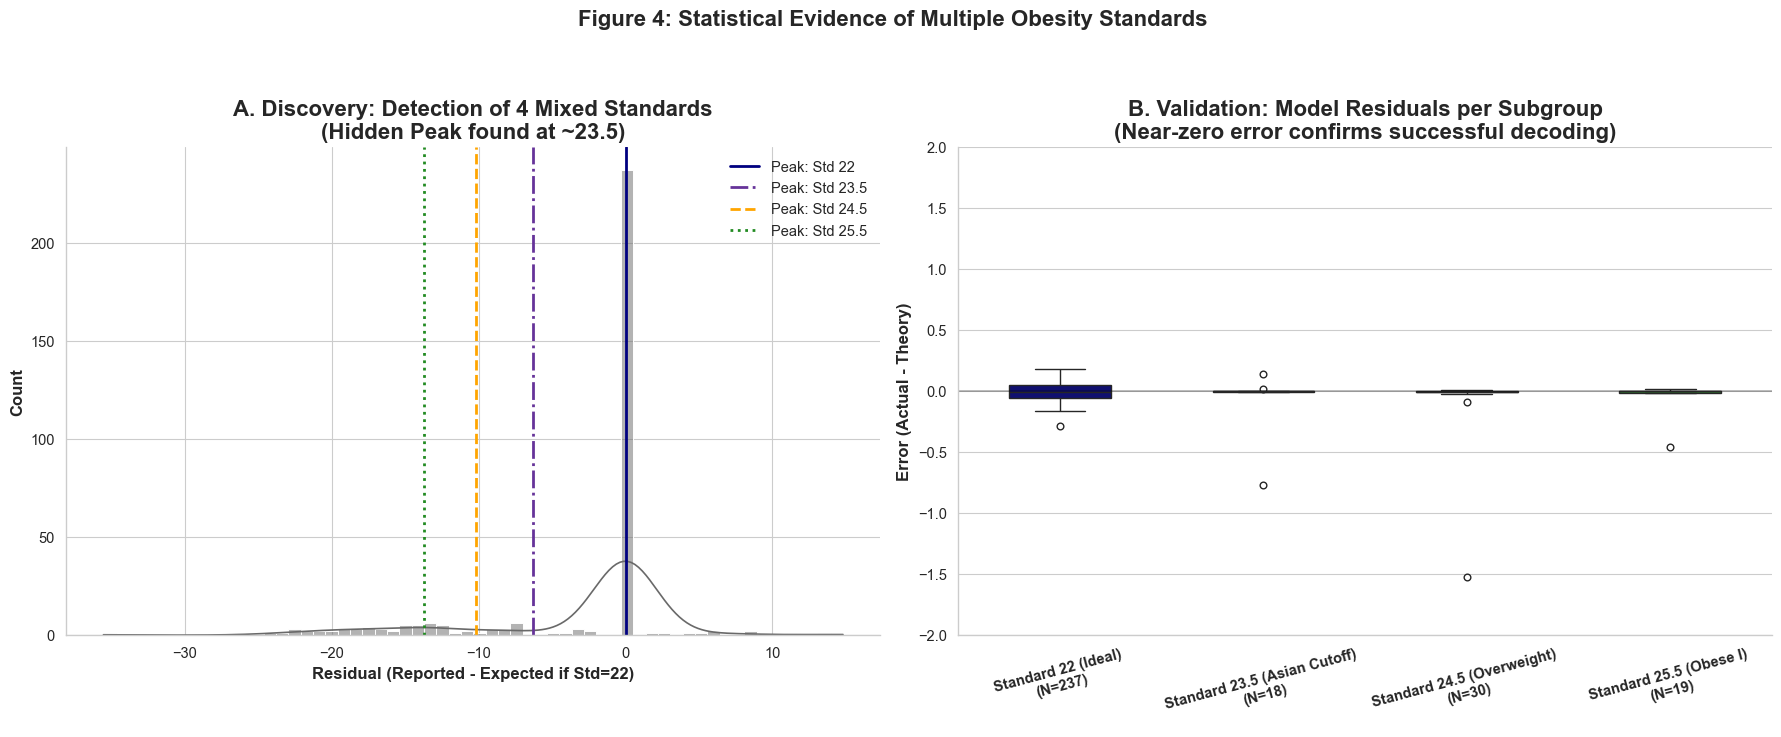

In [13]:
# ==============================================================================
# FIGURE 4: FORENSIC DISCOVERY & VALIDATION (The Evidence Chain)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ---------------------------------------------------------
# PANEL A: The Histogram (Discovery)
# ---------------------------------------------------------
ax1 = axes[0]
plot_df = df_bmi_profile[df_bmi_profile['Obesity (%)'] < 500]

sns.histplot(data=plot_df, x='Forensic_Residual_22', bins=60, kde=True, color='dimgray', ax=ax1)

# 标注 4 个峰值 (Fingerprints)
ax1.axvline(0, color='navy', linestyle='-', lw=2, label='Peak: Std 22')
ax1.axvline(-6.3, color='rebeccapurple', linestyle='-.', lw=2, label='Peak: Std 23.5')
ax1.axvline(-10.2, color='orange', linestyle='--', lw=2, label='Peak: Std 24.5')
ax1.axvline(-13.7, color='forestgreen', linestyle=':', lw=2, label='Peak: Std 25.5')

ax1.set_title("A. Discovery: Detection of 4 Mixed Standards\n(Hidden Peak found at ~23.5)", fontweight='bold')
ax1.set_xlabel("Residual (Reported - Expected if Std=22)")
ax1.legend()

# ---------------------------------------------------------
# PANEL B: The Boxplot (Validation)
# ---------------------------------------------------------
ax2 = axes[1]

valid_groups = ['Standard 22 (Ideal)', 'Standard 23.5 (Asian Cutoff)', 'Standard 24.5 (Overweight)', 'Standard 25.5 (Obese I)']
boxplot_df = df_bmi_profile[df_bmi_profile['Forensic_Group'].isin(valid_groups)]

# 计算样本量用于标签
counts = boxplot_df['Forensic_Group'].value_counts()
new_labels = [f"{g}\n(N={counts[g]})" for g in valid_groups]

sns.boxplot(data=boxplot_df, x='Forensic_Group', y='Model_Residual',
            palette=FORENSIC_PALETTE, width=0.5, ax=ax2, order=valid_groups)

ax2.axhline(0, color='black', linestyle='-', alpha=0.3)
ax2.set_title("B. Validation: Model Residuals per Subgroup\n(Near-zero error confirms successful decoding)", fontweight='bold')
ax2.set_ylabel("Error (Actual - Theory)")
ax2.set_xlabel(None)
ax2.set_xticklabels(new_labels, rotation=15, fontweight='bold')
ax2.set_ylim(-2, 2)

plt.suptitle("Figure 4: Statistical Evidence of Multiple Obesity Standards", y=1.05, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

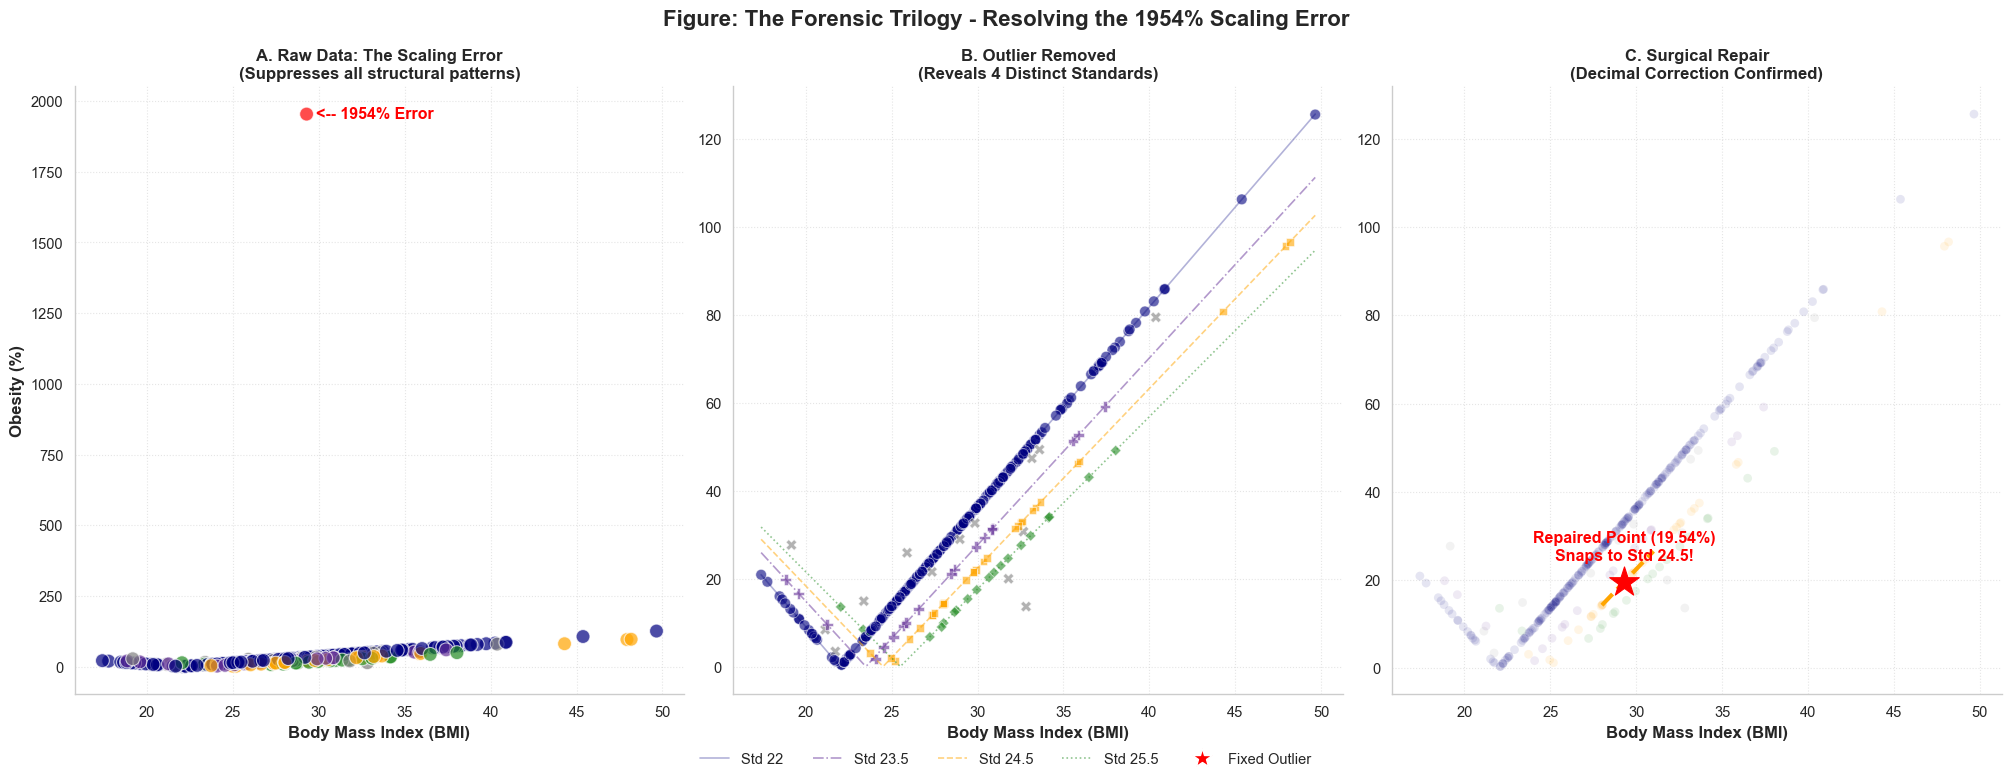

In [14]:
# ==============================================================================
# FIGURE: THE FORENSIC TRILOGY (Resolving the 1954% Error)
# ==============================================================================

# 1. SETUP CANVAS (1 Row, 3 Columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

# ---------------------------------------------------------
# ACT 1: THE CRIME SCENE (Raw Data)
# ---------------------------------------------------------
ax1 = axes[0]
sns.scatterplot(data=df_bmi_profile, x='BMI_Final', y='Obesity (%)',
                hue='Forensic_Group', palette=FORENSIC_PALETTE,
                s=100, alpha=0.7, ax=ax1, legend=False)

# Annotate the outlier
outlier = df_bmi_profile[mask_scaling]
if not outlier.empty:
    ax1.text(outlier['BMI_Final'].values[0], outlier['Obesity (%)'].values[0],
             "  <-- 1954% Error", color='red', fontweight='bold', va='center')

ax1.set_title("A. Raw Data: The Scaling Error\n(Suppresses all structural patterns)", fontweight='bold', fontsize=12)
ax1.set_xlabel("Body Mass Index (BMI)")
ax1.set_ylabel("Obesity (%)")
ax1.grid(True, linestyle=':', alpha=0.5)

# ---------------------------------------------------------
# ACT 2: THE INVESTIGATION (Outlier Removed)
# ---------------------------------------------------------
ax2 = axes[1]
# Zoom in (Filter out the outlier)
zoom_df = df_bmi_profile[df_bmi_profile['Obesity (%)'] < 500].copy()

sns.scatterplot(data=zoom_df, x='BMI_Final', y='Obesity (%)',
                hue='Forensic_Group', style='Forensic_Group', palette=FORENSIC_PALETTE,
                s=60, alpha=0.6, ax=ax2, legend=False)

# Draw 4 Theoretical Lines
x_range = np.linspace(zoom_df['BMI_Final'].min(), zoom_df['BMI_Final'].max(), 200)
ax2.plot(x_range, np.abs((x_range-22)/22)*100, color='navy', alpha=0.3, label='Std 22')
ax2.plot(x_range, np.abs((x_range-23.5)/23.5)*100, color='rebeccapurple', ls='-.', alpha=0.5, label='Std 23.5')
ax2.plot(x_range, np.abs((x_range-24.5)/24.5)*100, color='orange', ls='--', alpha=0.5, label='Std 24.5')
ax2.plot(x_range, np.abs((x_range-25.5)/25.5)*100, color='forestgreen', ls=':', alpha=0.5, label='Std 25.5')

ax2.set_title("B. Outlier Removed\n(Reveals 4 Distinct Standards)", fontweight='bold', fontsize=12)
ax2.set_xlabel("Body Mass Index (BMI)")
ax2.set_ylabel(None)
ax2.grid(True, linestyle=':', alpha=0.5)

# ---------------------------------------------------------
# ACT 3: THE CORRECTION (The Fix)
# ---------------------------------------------------------
ax3 = axes[2]
# Background (faded)
sns.scatterplot(data=zoom_df, x='BMI_Final', y='Obesity (%)',
                hue='Forensic_Group', palette=FORENSIC_PALETTE,
                s=40, alpha=0.1, ax=ax3, legend=False)

# The Fix
if not outlier.empty:
    fixed_bmi = outlier['BMI_Final'].values[0]
    fixed_obesity = outlier['Obesity (%)'].values[0] / 100 # Decimal Correction

    # Plot Star
    ax3.scatter(fixed_bmi, fixed_obesity, color='red', marker='*', s=500, zorder=10, label='Corrected (19.54%)')

    # Draw matching line (Std 24.5)
    x_local = np.linspace(28, 31, 20)
    ax3.plot(x_local, np.abs((x_local - 24.5)/24.5)*100, color='orange', ls='--', lw=3, label='Std 24.5 Trend')

    # Annotation
    ax3.text(fixed_bmi, fixed_obesity + 5, "Repaired Point (19.54%)\nSnaps to Std 24.5!",
             ha='center', color='red', fontweight='bold')

ax3.set_title("C. Surgical Repair\n(Decimal Correction Confirmed)", fontweight='bold', fontsize=12)
ax3.set_xlabel("Body Mass Index (BMI)")
ax3.set_ylabel(None)
ax3.grid(True, linestyle=':', alpha=0.5)

# Unified Legend
handles, labels = ax2.get_legend_handles_labels()
star = Line2D([0], [0], color='w', marker='*', markerfacecolor='red', markersize=15, label='Fixed Outlier')
handles.append(star)
fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=6, frameon=False)

plt.suptitle("Figure: The Forensic Trilogy - Resolving the 1954% Scaling Error", y=1.05, fontsize=16, fontweight='bold')
plt.show()